#### Import libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load dataset

In [23]:
df = pd.read_csv('Dataset\student_habits_performance.csv')

#### Top 5 Records

In [24]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


#### Shape of the dataser

In [25]:
df.shape

(1000, 16)

#### Data tpye of Columns

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

#### Check missing values

In [27]:
df.isna().values.any()

np.True_

#### Check for duplicate values

In [28]:
df.duplicated().values.any()

np.False_

### Statistical Summary

In [29]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [30]:
df.describe(include="object")

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1000,1000,1000,1000,909,1000,1000
unique,1000,3,2,3,3,3,2
top,S1999,Female,No,Fair,High School,Good,No
freq,1,481,785,437,392,447,682


#### Correlation between columns

In [31]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.003971,-0.009151,-0.001174,-0.026055,0.037482,-0.003836,-0.045101,-0.008907
study_hours_per_day,0.003971,1.000000,0.020282,-0.031158,0.026264,-0.027757,-0.028701,-0.003768,0.825419
social_media_hours,-0.009151,0.020282,1.000000,0.011477,0.040479,0.018236,-0.037319,0.001496,-0.166733
netflix_hours,-0.001174,-0.031158,0.011477,1.000000,-0.002092,-0.000935,-0.006448,0.008034,-0.171779
attendance_percentage,-0.026055,0.026264,0.040479,-0.002092,1.000000,0.013756,-0.007857,-0.018745,0.089836
sleep_hours,0.037482,-0.027757,0.018236,-0.000935,0.013756,1.000000,0.019769,-0.006508,0.121683
exercise_frequency,-0.003836,-0.028701,-0.037319,-0.006448,-0.007857,0.019769,1.000000,-0.000242,0.160107
mental_health_rating,-0.045101,-0.003768,0.001496,0.008034,-0.018745,-0.006508,-0.000242,1.000000,0.321523
exam_score,-0.008907,0.825419,-0.166733,-0.171779,0.089836,0.121683,0.160107,0.321523,1.000000


In [32]:
df.corr(numeric_only=True)['exam_score']

age                     -0.008907
study_hours_per_day      0.825419
social_media_hours      -0.166733
netflix_hours           -0.171779
attendance_percentage    0.089836
sleep_hours              0.121683
exercise_frequency       0.160107
mental_health_rating     0.321523
exam_score               1.000000
Name: exam_score, dtype: float64

In [33]:
numerical_columns = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
categorical_columns = ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']

#### Histogram

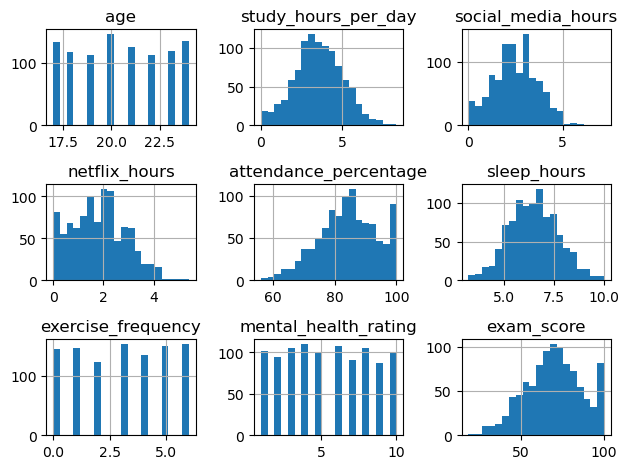

In [34]:
df.hist(bins=20)
plt.tight_layout()
plt.show()

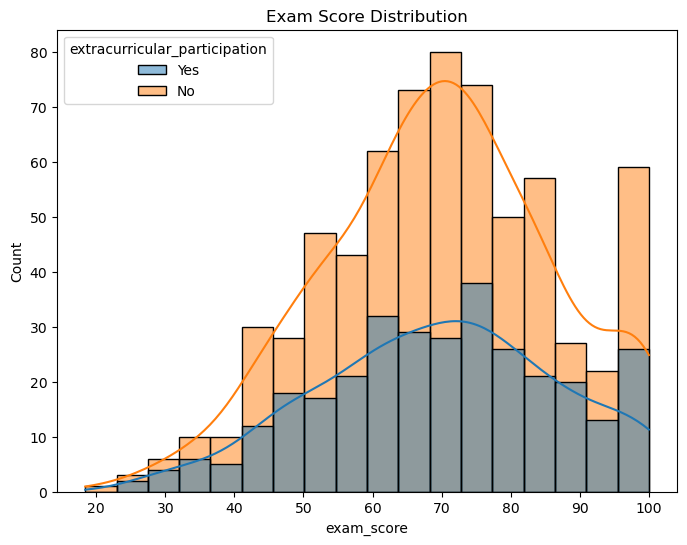

In [35]:
plt.figure(figsize=(8, 6))
sns.histplot(df, x='exam_score', kde=True, hue='extracurricular_participation')
plt.title('Exam Score Distribution')
plt.show()

#### Count Plot

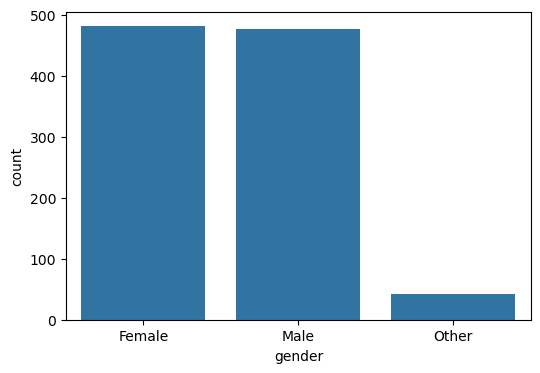

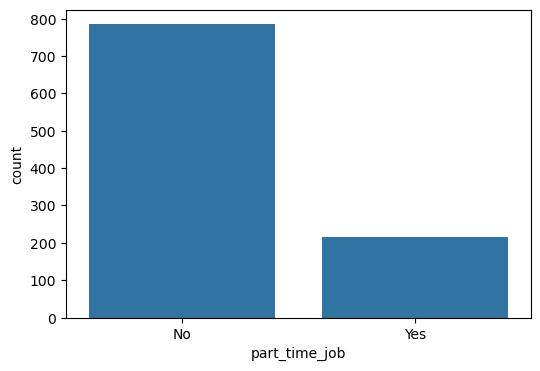

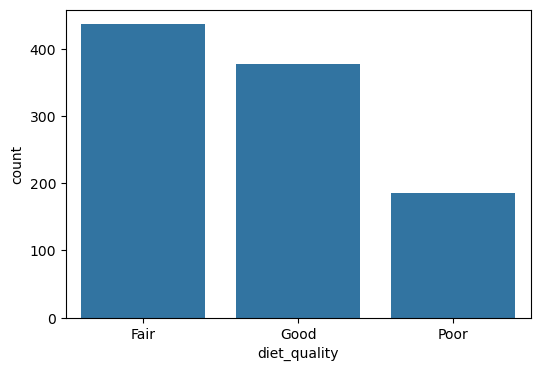

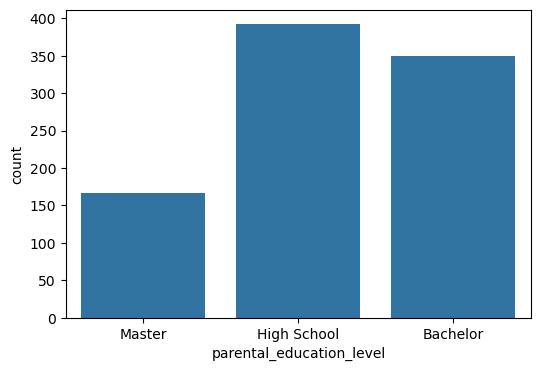

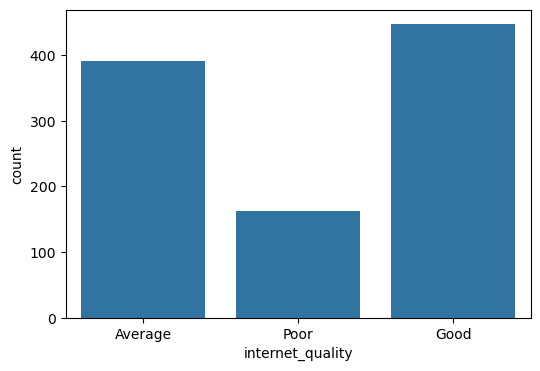

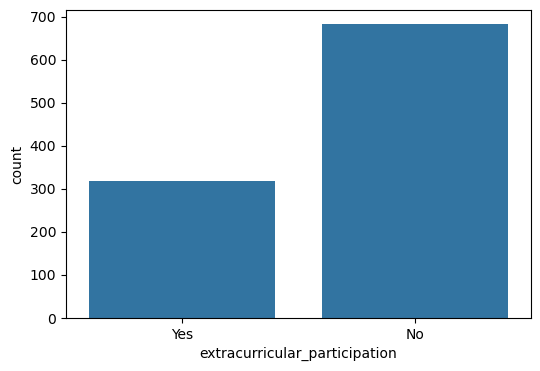

In [36]:
for col in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df,x=col)
    plt.xlabel(col)
    plt.show()

#### Box plot

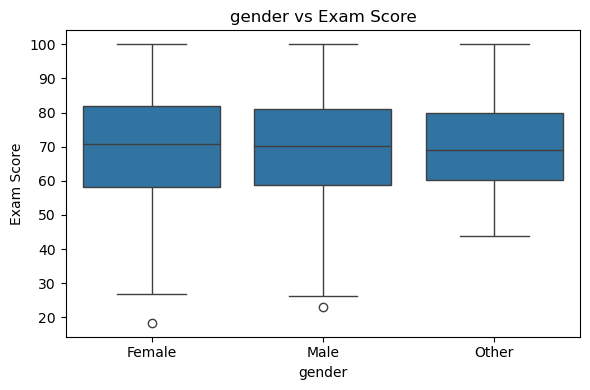

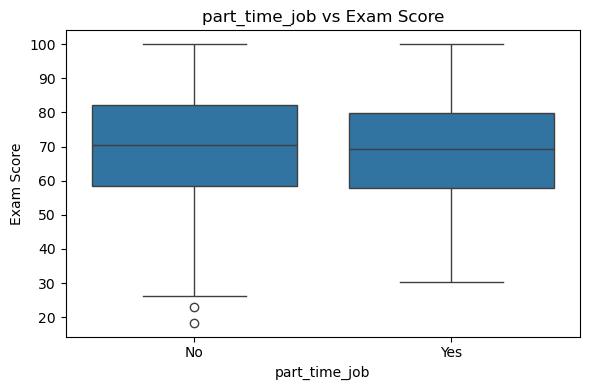

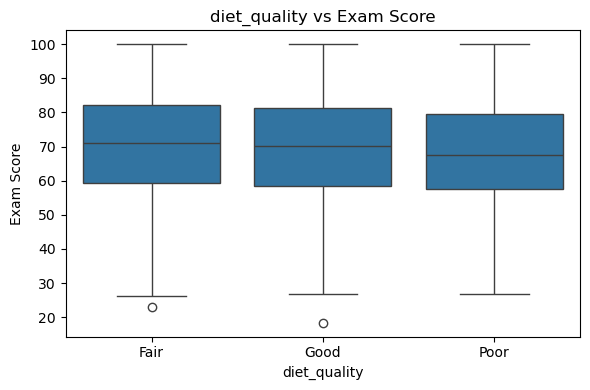

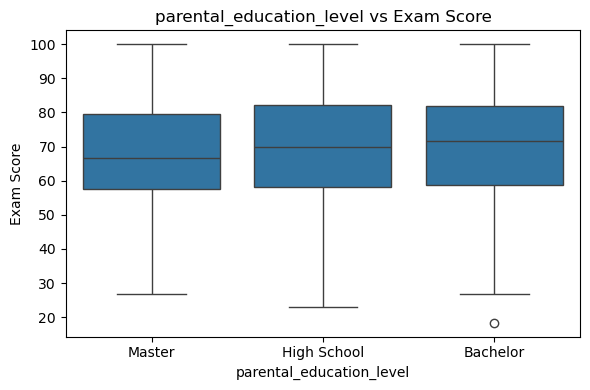

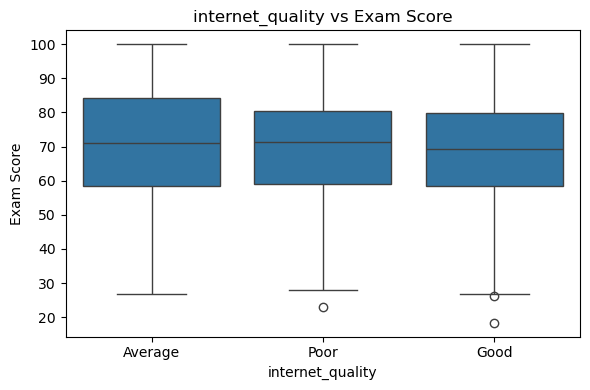

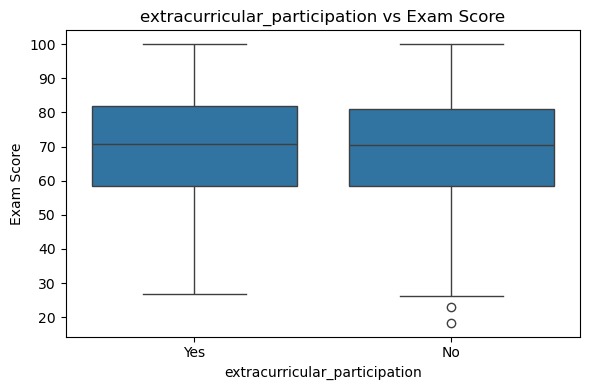

In [37]:
for col in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df,x=col, y="exam_score")
    plt.title(f"{col} vs Exam Score")
    plt.xlabel(col)
    plt.ylabel("Exam Score")
    plt.tight_layout()
    plt.show()

#### Scatrer plot

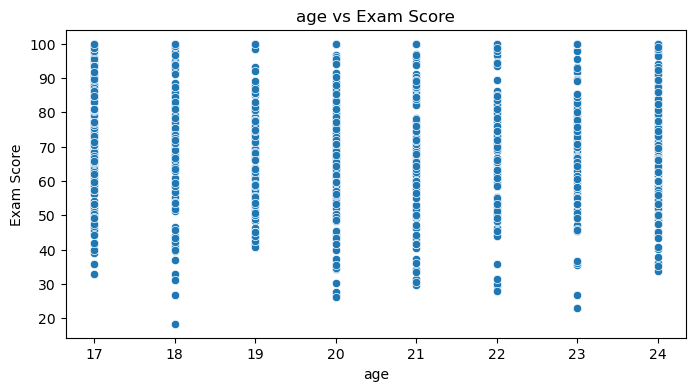

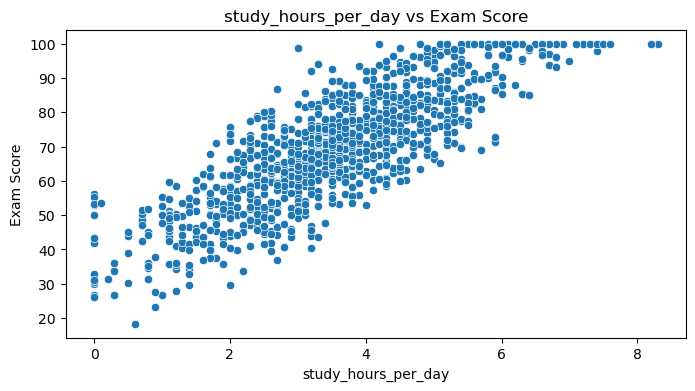

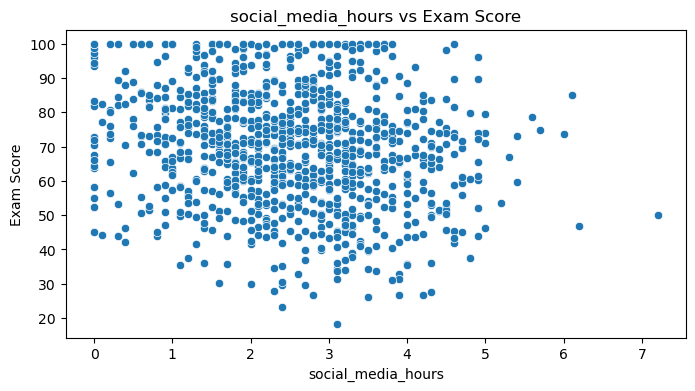

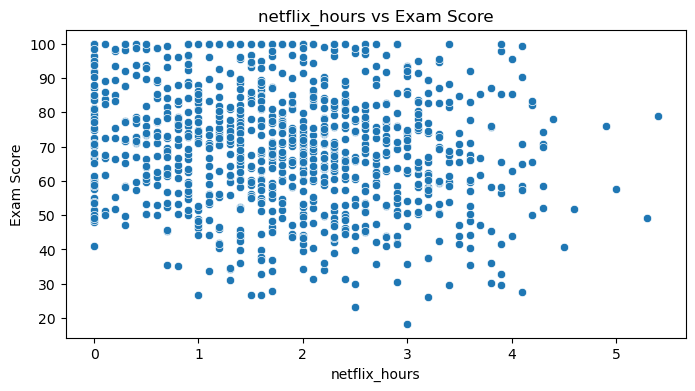

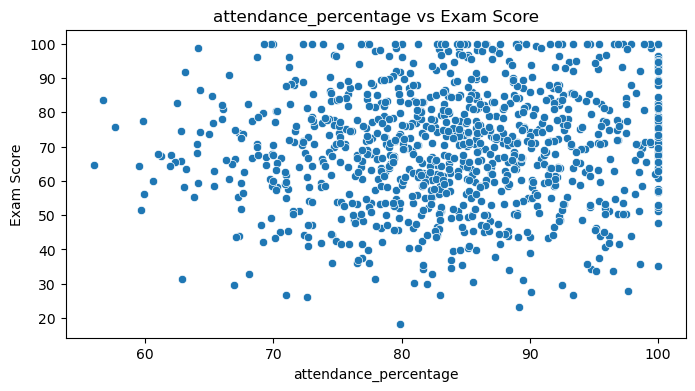

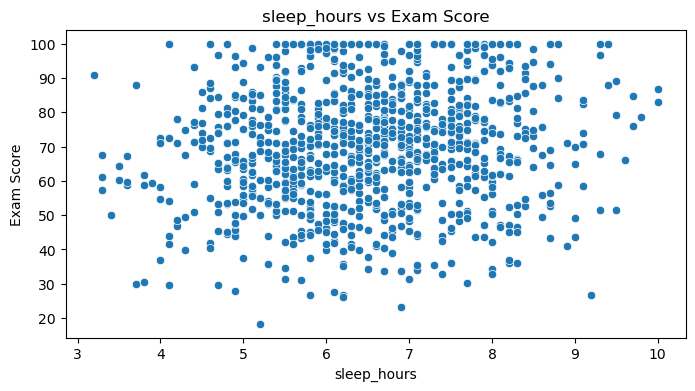

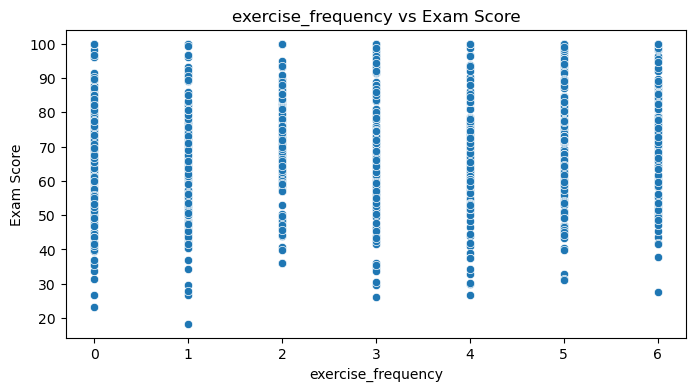

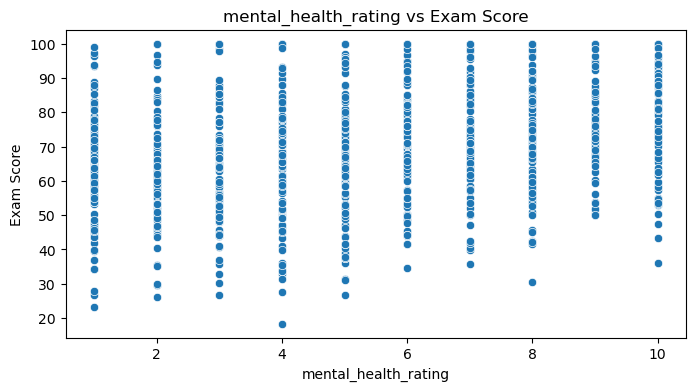

In [38]:
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.scatterplot( data=df,x=col,y="exam_score")
    plt.title(f"{col} vs Exam Score")
    plt.xlabel(col)
    plt.ylabel("Exam Score")

    plt.show()

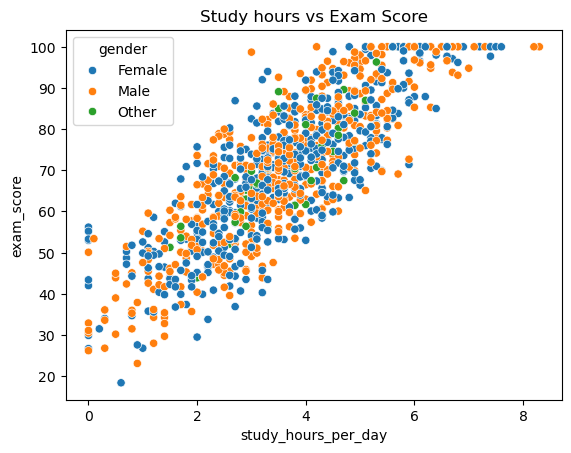

In [39]:
sns.scatterplot(df, x='study_hours_per_day', y='exam_score', hue='gender')
plt.title('Study hours vs Exam Score')
plt.show()

#### Heatmap

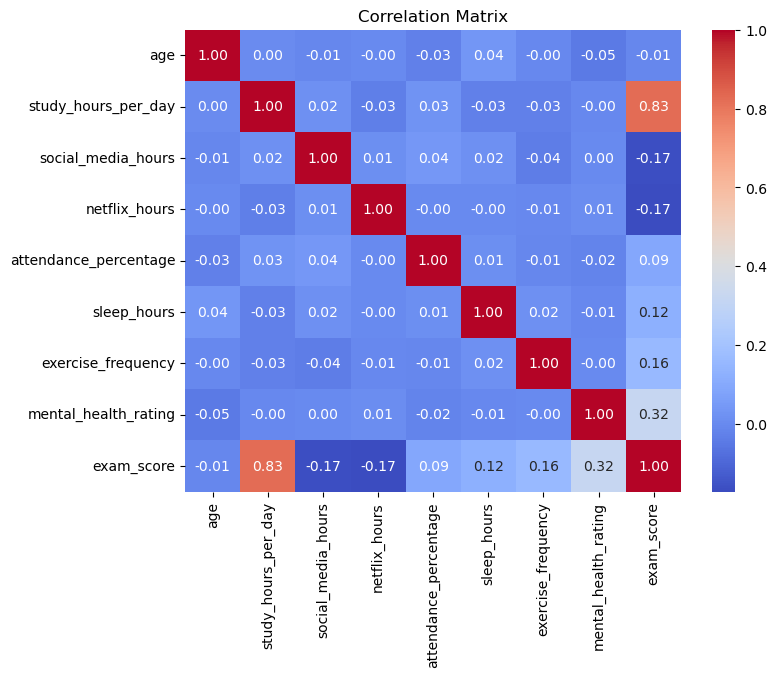

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

#### Pair plot

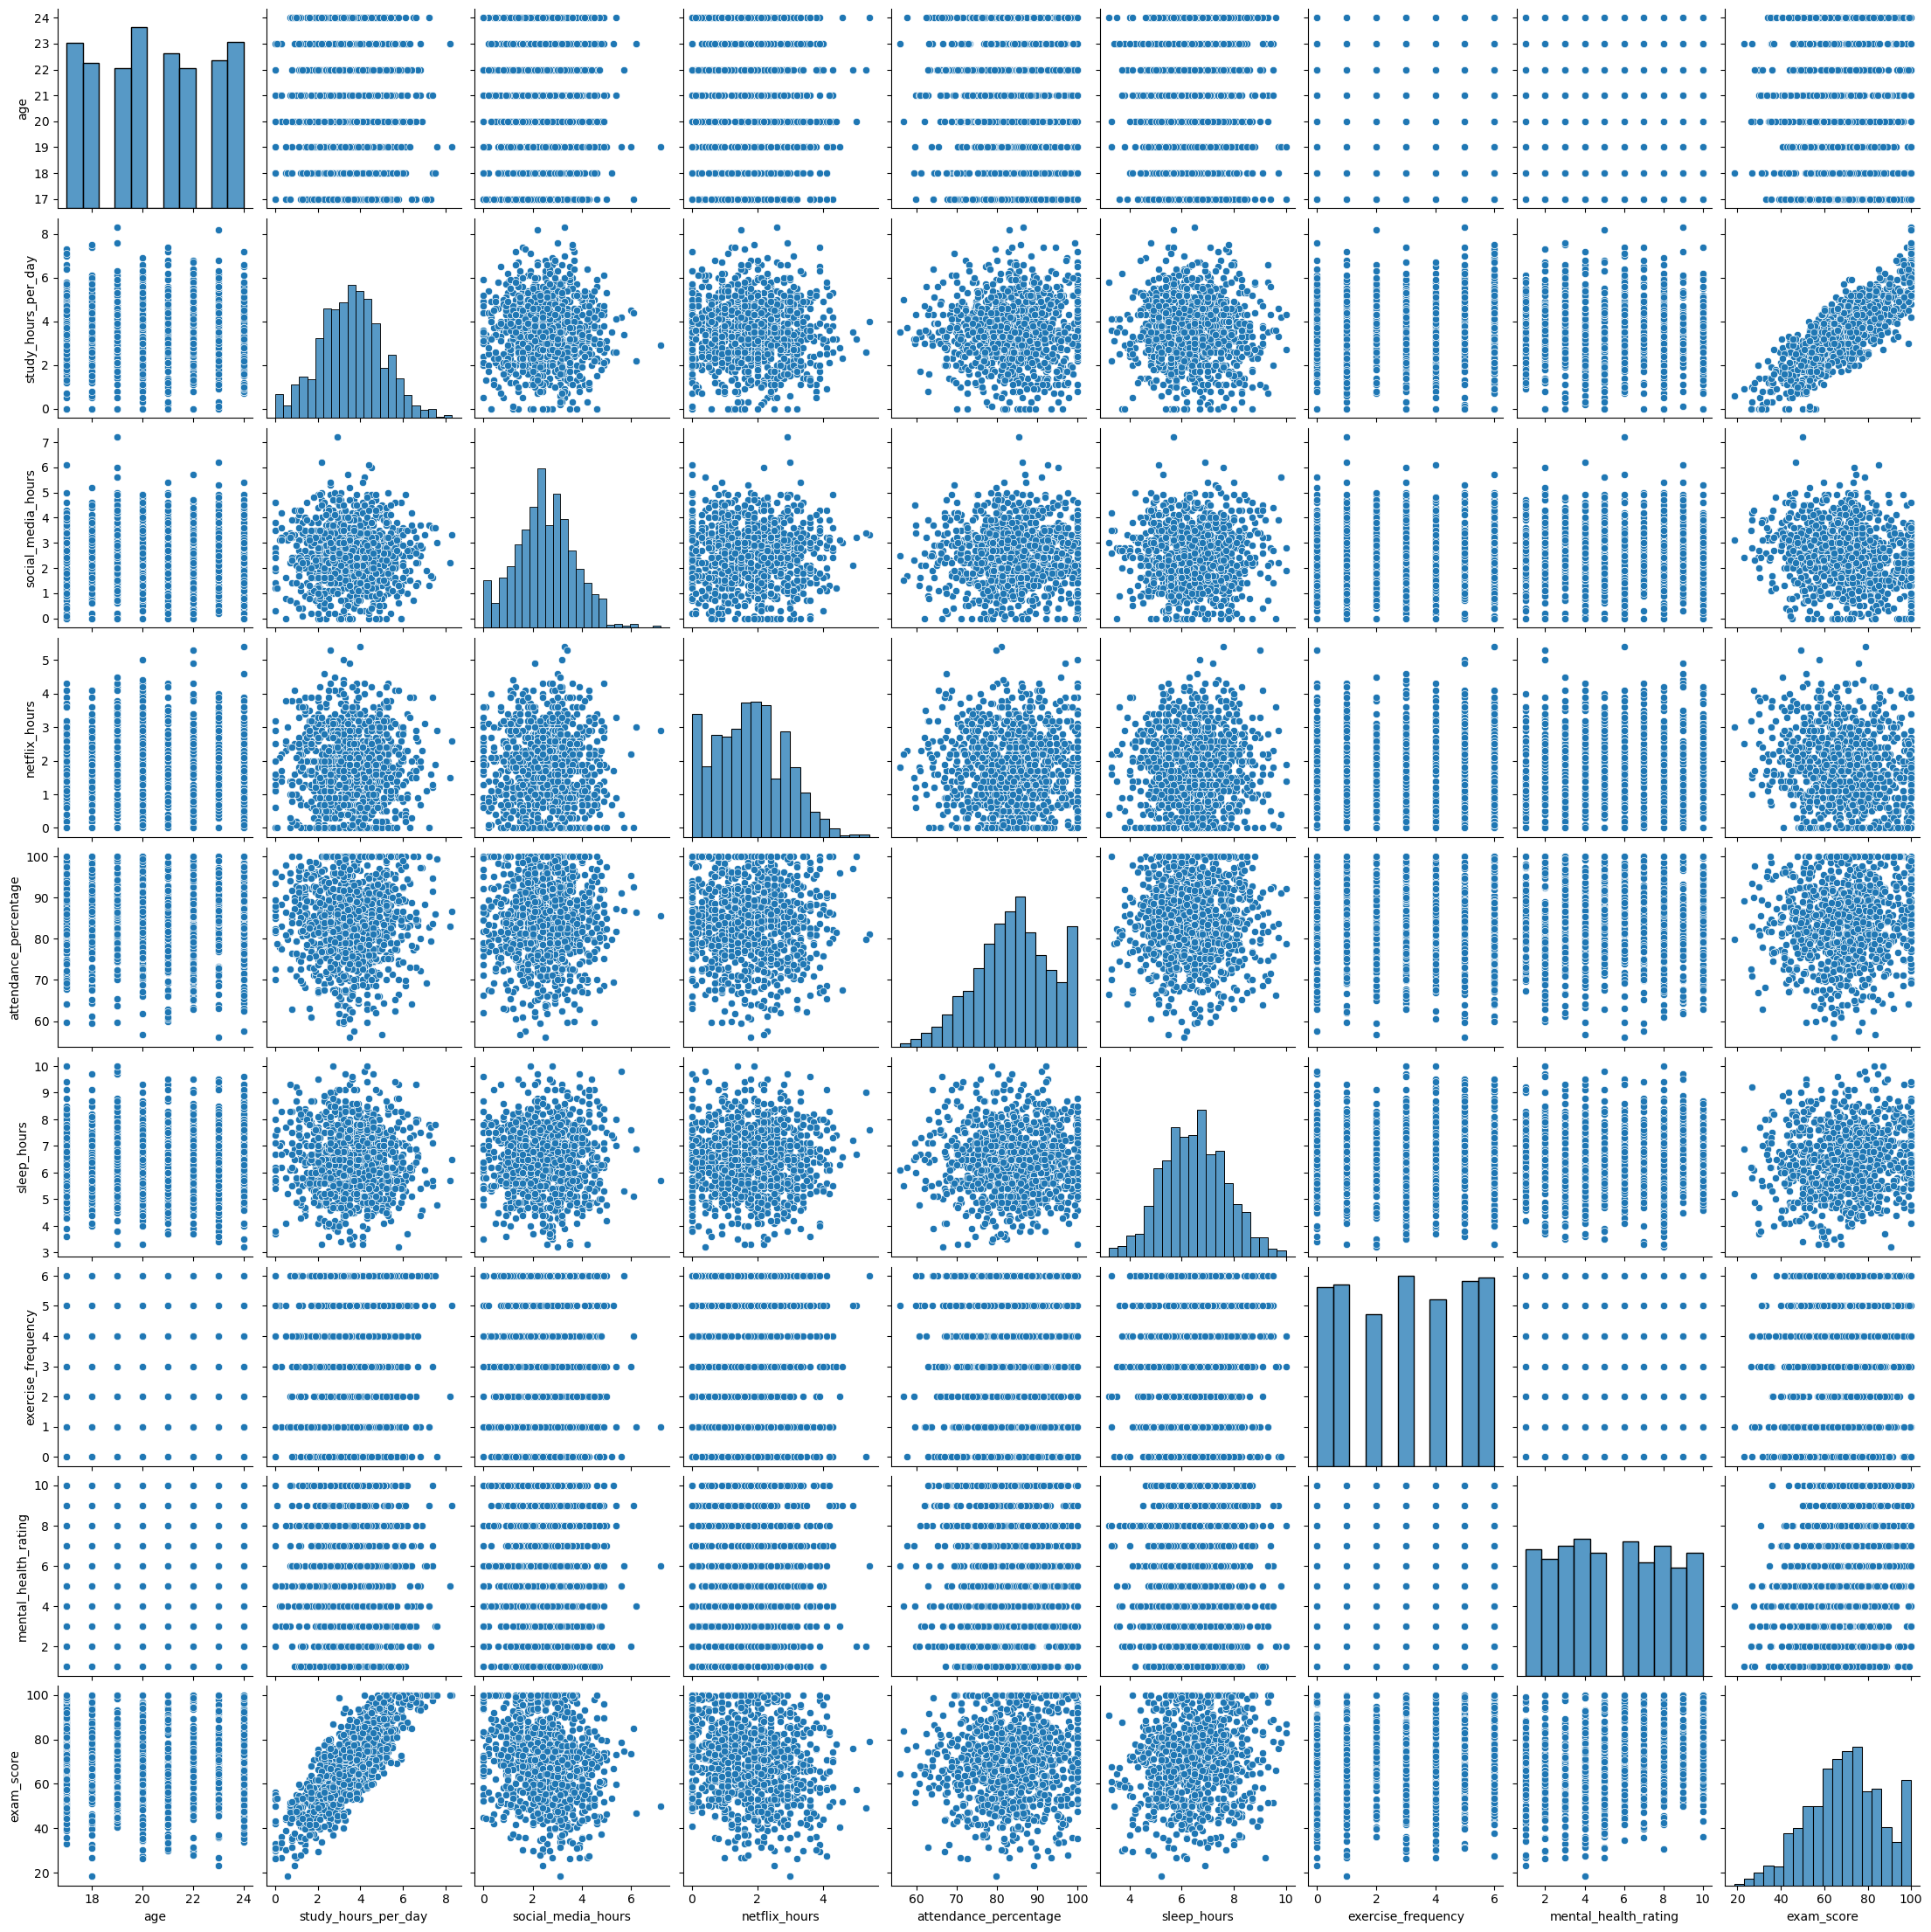

In [41]:
sns.pairplot(df)

## Dectect outlires in *exam_score*

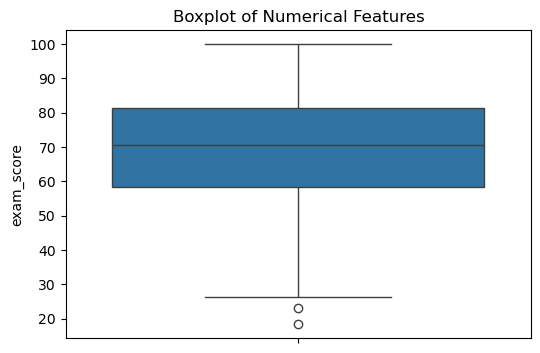

In [42]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df['exam_score']
)

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)

plt.show()

In [43]:
Q1 = df["exam_score"].quantile(0.25)
Q3 = df["exam_score"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["exam_score"] < lower_bound) |
    (df["exam_score"] > upper_bound)
]
print("Number of exam score outliers:", len(outliers))
outliers

Number of exam score outliers: 2


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
265,S1265,18,Female,0.6,3.1,3.0,No,79.9,5.2,Good,1,Bachelor,Good,4,No,18.4
327,S1327,23,Male,0.9,2.4,2.5,No,89.2,6.9,Fair,0,High School,Poor,1,No,23.1


### Number of student who score less than 30

In [44]:
stud_score_less_than_30 = df[df['exam_score'] <= 30]
print(f'{len(stud_score_less_than_30)} students has marks less than 30')

11 students has marks less than 30


### Number od student who score more than 90

In [ ]:
stud_score_more_than_90 = df[df['exam_score'] >= 90]
print(f'{len(stud_score_more_than_90)} students has marks more than 90')

126 students has marks more than 90


### Number of student who score full marks

In [46]:
stud_score_full = df[df['exam_score'] == 100]
print(f'{len(stud_score_full)} students get full marks')

48 students get full marks
